In [1]:
!pip install pandas
!pip install seaborn
!python.exe -m pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


# Question 1

# Load dataset 
This block loads the energy efficiency dataset, shows its dimensions, and displays the first few records for an initial overview.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
energy_efficiency = pd.read_csv(r"C:\Users\akhil_s\Desktop\DS_AS2\energy_efficiency.csv")
display(energy_efficiency)
print("Shape:", energy_efficiency.shape)
display(energy_efficiency.head())

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


Shape: (768, 10)


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [3]:
display(energy_efficiency.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


None

In [4]:
display(energy_efficiency.isnull().sum())

Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64

In [5]:
display(energy_efficiency.describe())

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


##  Distribution of Numerical Features
Let's visualize how each variable is distributed.


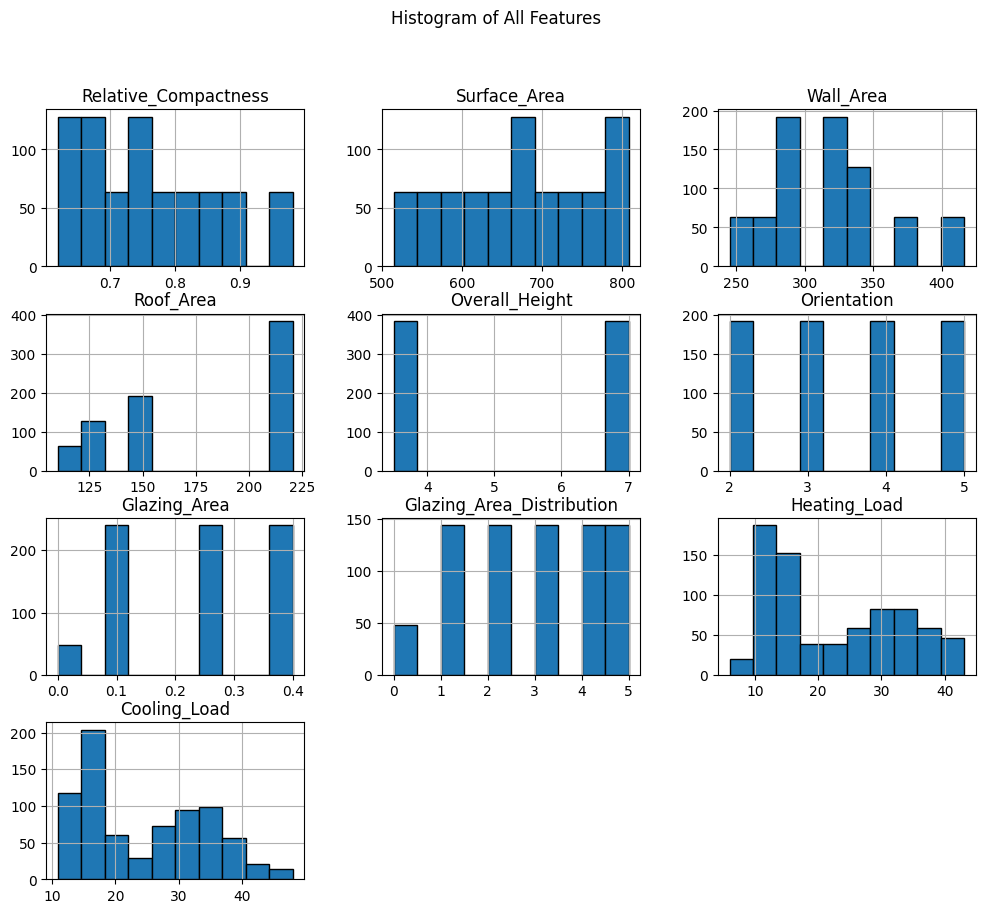

In [6]:
energy_efficiency.hist(figsize=(12, 10), bins=10, edgecolor='black')
plt.suptitle("Histogram of All Features")
plt.show()

## Boxplots for Outlier Detection
Boxplots help identify extreme values in the dataset.


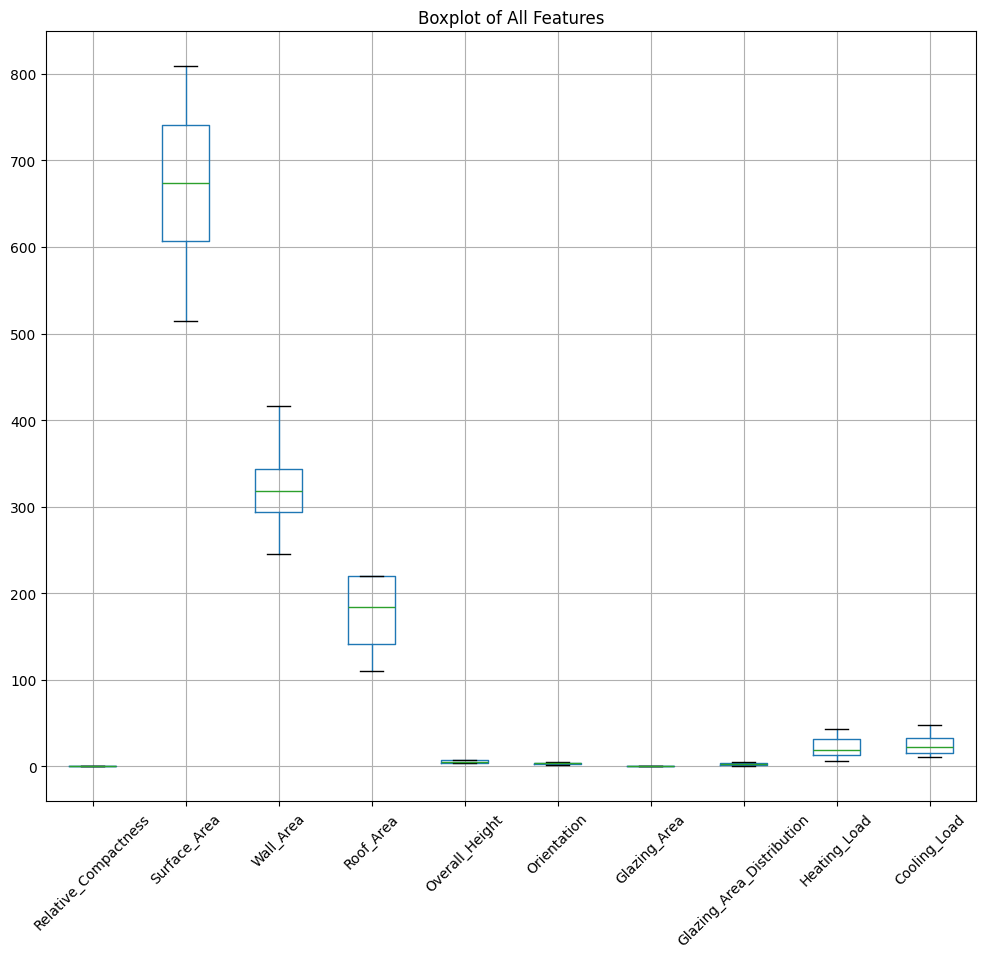

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
energy_efficiency.boxplot()
plt.title("Boxplot of All Features")
plt.xticks(rotation=45)
plt.show()

# point : 2
Visualizing Relationships Between Features and Targets

Overall_Height, Relative_Compactness, and Surface_Area strongly influence energy loads.

Heating and Cooling loads are highly correlated.

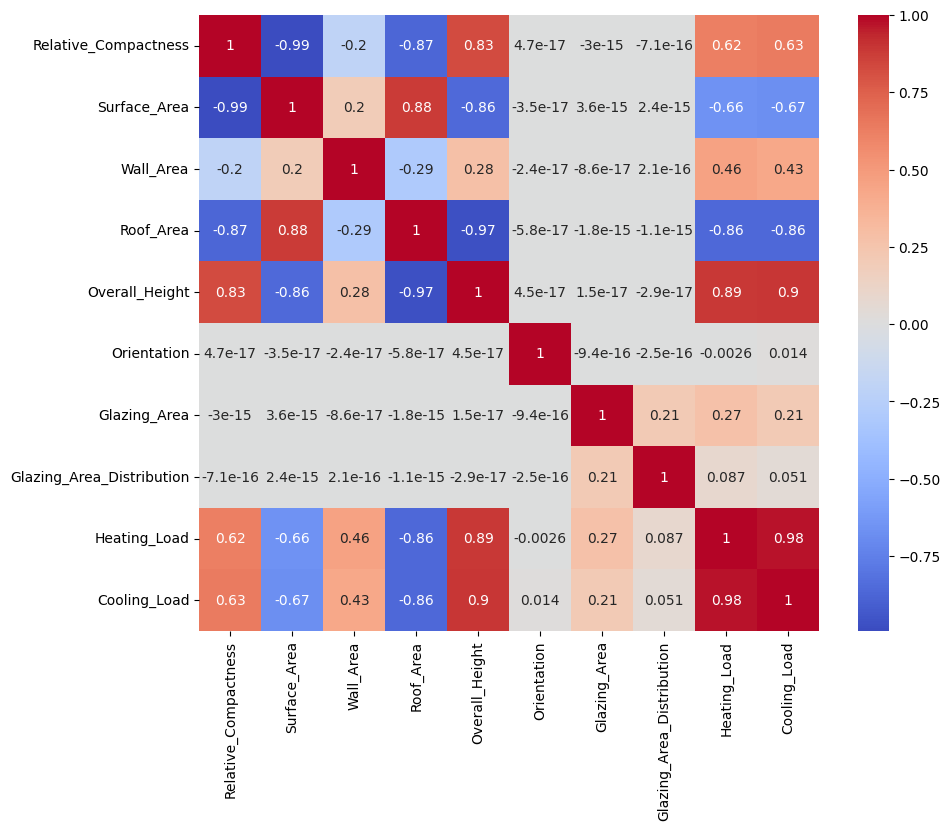

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(energy_efficiency.corr(), annot=True, cmap="coolwarm")
plt.show()

# Feature vs Target Scatter Plots

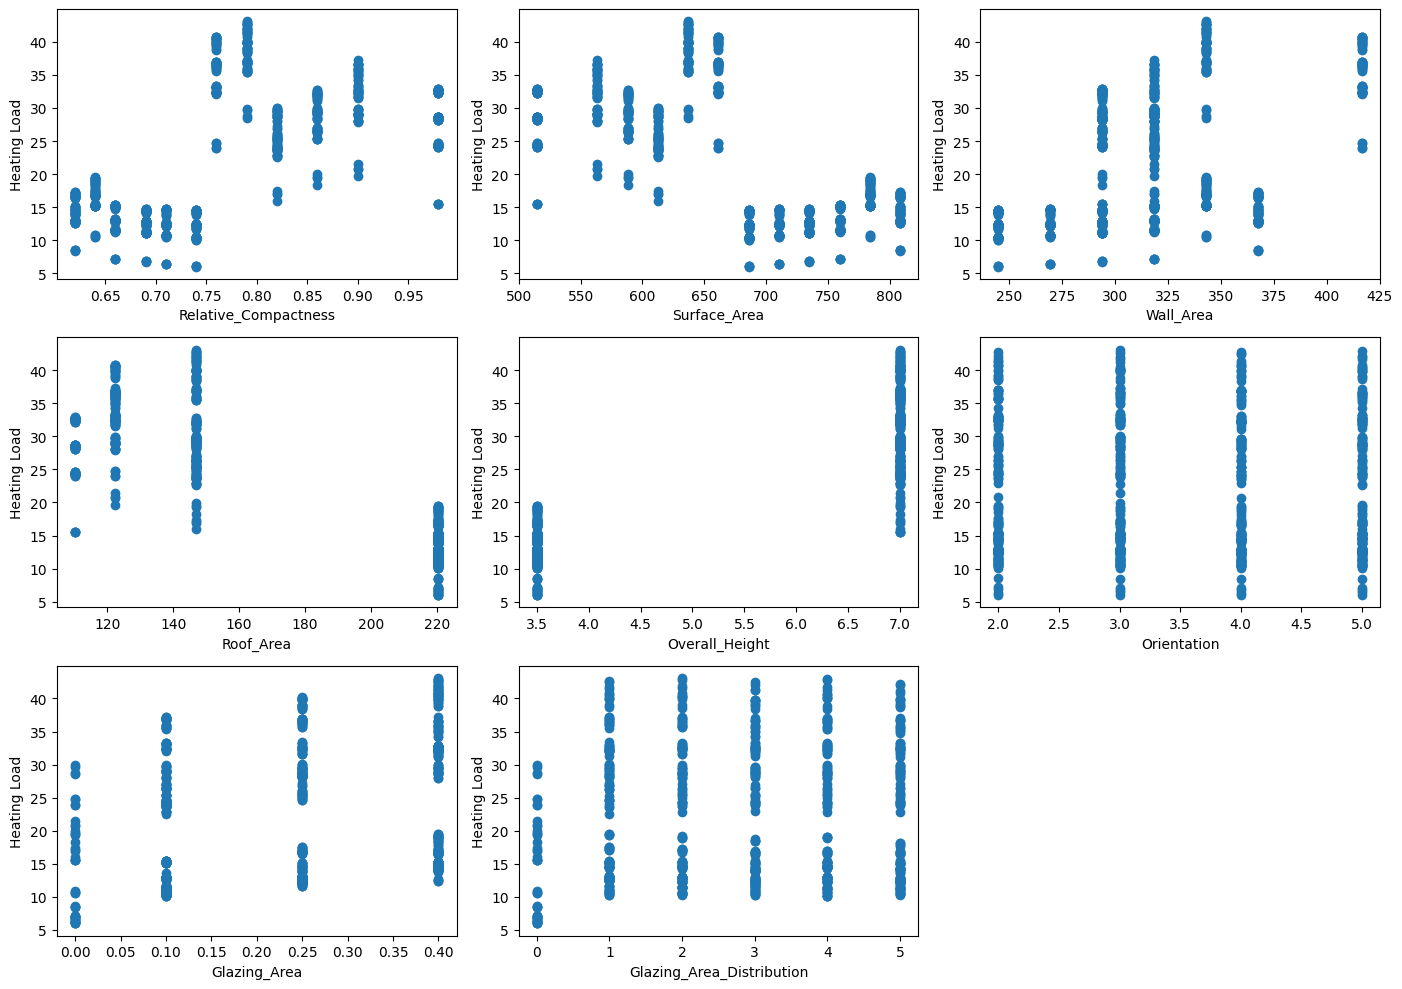

In [9]:
features = energy_efficiency.columns[:-2]
plt.figure(figsize=(14, 10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    
    plt.scatter(energy_efficiency[col], energy_efficiency['Heating_Load'])
    plt.xlabel(col)
    plt.ylabel('Heating Load')
    
plt.tight_layout()
plt.show()

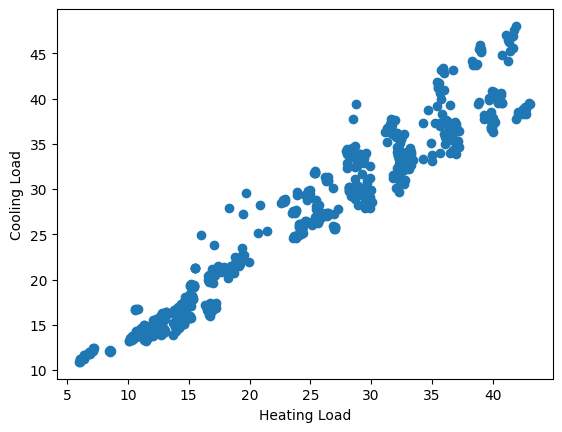

In [10]:
plt.scatter(energy_efficiency['Heating_Load'], energy_efficiency['Cooling_Load'])
plt.xlabel('Heating Load')
plt.ylabel('Cooling Load')
plt.show()

# Feature Selection and Transformation

Separate Features and Targets

In [11]:
X = energy_efficiency.drop(['Heating_Load', 'Cooling_Load'], axis=1)
y = energy_efficiency[['Heating_Load', 'Cooling_Load']]

### Feature Scaling

In [12]:
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature Importance Using Correlation

In [14]:
corr_with_target = energy_efficiency.corr()[['Heating_Load', 'Cooling_Load']]
corr_with_target

,Heating_Load,Cooling_Load
Relative_Compactness,0.622272,0.634339
Surface_Area,-0.658120,-0.672999
Wall_Area,0.455671,0.427117
Roof_Area,-0.861828,-0.862547
Overall_Height,0.889431,0.895785
Orientation,-0.002587,0.014290
Glazing_Area,0.269841,0.207505
Glazing_Area_Distribution,0.087368,0.050525
Heating_Load,1.000000,0.975862
Cooling_Load,0.975862,1.000000


# Question : 2

Apply Regression Models (Linear, Ridge, and Lasso)

In this section, we apply three regression models to predict the energy efficiency targets. The models chosen are:

Linear Regression

Ridge Regression

Lasso Regression

The goal is to compare their performance in a simple and understandable way.

In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


##  Split the Dataset

The dataset is divided into training and testing sets.  
The training set is used to build the model, while the testing set is used to evaluate its performance.


In [16]:
X = energy_efficiency.drop(['Heating_Load', 'Cooling_Load'], axis=1)
y = energy_efficiency['Heating_Load']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


##  Linear Regression Model

Linear Regression is used as a baseline model to understand the relationship between input features and the target variable.


In [17]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

mse_linear, r2_linear

(9.153187855202752, 0.912184095154691)

##  Ridge Regression Model

Ridge Regression applies L2 regularization, which helps reduce overfitting by penalizing large coefficients.


In [18]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

mse_ridge, r2_ridge


(9.653457481031017, 0.9073844963095998)

## Lasso Regression Model

Lasso Regression uses L1 regularization and can reduce some feature coefficients to zero, effectively performing feature selection.


In [19]:
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

mse_lasso, r2_lasso

(9.74292973033666, 0.9065260973937671)

## Model Performance Comparison

The models are compared using Mean Squared Error (MSE) and R² Score.


In [20]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "MSE": [mse_linear, mse_ridge, mse_lasso],
    "R2 Score": [r2_linear, r2_ridge, r2_lasso]
})

results

,Model,MSE,R2 Score
0,Linear Regression,9.153188,0.912184
1,Ridge Regression,9.653457,0.907384
2,Lasso Regression,9.742930,0.906526


## point 2


##  Define Features and Target Variable

The input features are separated from the target variable.  
Heating Load is selected as the target for prediction.


In [21]:
X = energy_efficiency.drop(['Heating_Load', 'Cooling_Load'], axis=1)
y = energy_efficiency['Heating_Load']

##  Split the Data into Training and Testing Sets

The dataset is divided into 80% training data and 20% testing data.
This helps evaluate how well the model performs on unseen data.


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


##  Train Linear Regression Model

Linear Regression is used as a baseline model to predict the Heating Load.


In [23]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

##  Evaluate Linear Regression Model

Model performance is measured using Mean Squared Error (MSE) and R² Score.


In [24]:
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

mse_linear, r2_linear


(9.153187855202752, 0.912184095154691)

## Train Ridge Regression Model

Ridge Regression applies regularization to reduce model overfitting.


In [25]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

##  Evaluate Ridge Regression Model


In [26]:
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

mse_ridge, r2_ridge

(9.653457481031017, 0.9073844963095998)

##  Train Lasso Regression Model

Lasso Regression can eliminate less important features by shrinking coefficients to zero.


In [27]:
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

##  Evaluate Lasso Regression Model


In [28]:
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

mse_lasso, r2_lasso


(9.74292973033666, 0.9065260973937671)

##  Compare Model Performance

The results of all models are summarized to compare their accuracy.


In [29]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MSE': [mse_linear, mse_ridge, mse_lasso],
    'R2 Score': [r2_linear, r2_ridge, r2_lasso]
})

results

,Model,MSE,R2 Score
0,Linear Regression,9.153188,0.912184
1,Ridge Regression,9.653457,0.907384
2,Lasso Regression,9.742930,0.906526


# point 3
## Select the Best Performing Model

Based on the evaluation metrics, the model with the highest R² score and lowest MSE is selected for making predictions.


In [30]:
best_model = ridge_model  # Selected based on model performance

##  Generate Predictions

The selected model is used to predict Heating Load values for the test dataset.


In [31]:
test_predictions = best_model.predict(X_test)

test_predictions[:5]

array([19.58365264, 13.82320076, 31.82579891, 35.55651985, 15.78688638])

##  Compare Actual and Predicted Values

A comparison table helps evaluate how close the predicted values are to the actual Heating Load values.


In [32]:
comparison = pd.DataFrame({
    'Actual Heating Load': y_test.values,
    'Predicted Heating Load': test_predictions
})

comparison.head()


,Actual Heating Load,Predicted Heating Load
0,16.47,19.583653
1,13.17,13.823201
2,32.82,31.825799
3,41.32,35.556520
4,16.69,15.786886


##  Predict Heating Load for a New Building Design

The model can be used to estimate Heating Load for future building configurations.


In [33]:
new_observation = pd.DataFrame({
    'Relative_Compactness': [0.85],
    'Surface_Area': [540.0],
    'Wall_Area': [320.0],
    'Roof_Area': [110.0],
    'Overall_Height': [7.0],
    'Orientation': [3],
    'Glazing_Area': [0.25],
    'Glazing_Area_Distribution': [4]
})

future_prediction = best_model.predict(new_observation)
future_prediction


array([31.01574361])

In [34]:
! pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

## Feature Scaling

Neural networks perform better when input features are scaled.
Standardization ensures all features contribute equally during training.


In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Build the Neural Network Model

A simple feedforward neural network with two hidden layers is created.
The model is intentionally kept small to reduce overfitting.


In [37]:
nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

C:\Users\akhil_s\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##  Compile the Model

The model is compiled using:
- Adam optimizer for efficient training
- Mean Squared Error as the loss function for regression


In [38]:
nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

##  Train the Neural Network

The model is trained using the training dataset and validated on the test dataset.


In [39]:
history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 577.2419 - val_loss: 600.7027
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 552.4473 - val_loss: 570.7510
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 517.7138 - val_loss: 525.9618
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 466.5212 - val_loss: 461.6508
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 396.4304 - val_loss: 374.7766
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 308.6422 - val_loss: 272.4062
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 212.6286 - val_loss: 171.4408
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 129.2134 - val_loss: 98.2622
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 74.4268 - val_loss: 59.9122
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 49.6518 - val_loss: 46.0715
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40.6999 - val_loss: 41.0170
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━

##  Make Predictions Using Neural Network


In [40]:
nn_predictions = nn_model.predict(X_test_scaled).flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


##  Evaluate Neural Network Performance

Model performance is evaluated using Mean Squared Error (MSE) and R² Score.


In [41]:
nn_mse = mean_squared_error(y_test, nn_predictions)
nn_r2 = r2_score(y_test, nn_predictions)

nn_mse, nn_r2

(11.930121750997126, 0.8855421244432322)

## point : 2 Import Required Libraries

This step imports the libraries required for building, training, and evaluating the neural network.


In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

## Feature Scaling

Neural networks require scaled input features to ensure stable and efficient training.
StandardScaler is used to normalize the input data.


In [43]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##  Build the Neural Network Model

A feedforward neural network with two hidden layers is used.
The architecture is designed to be simple while still capturing non-linear relationships.


In [44]:
nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

C:\Users\akhil_s\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##  Compile the Neural Network

The model is compiled using:
- Adam optimizer for efficient training
- Mean Squared Error loss for regression


In [45]:
nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

##  Train the Neural Network

The model is trained on the training dataset and validated using the test dataset.


In [46]:
history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 556.2135 - val_loss: 572.5072
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 523.0589 - val_loss: 532.4593
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 479.0443 - val_loss: 477.1228
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 417.8066 - val_loss: 403.2084
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 340.0122 - val_loss: 313.9512
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 253.5314 - val_loss: 224.2266
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 175.1070 - val_loss: 150.4862
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 117.3587 - val_loss: 105.6225
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 83.9604 - val_loss: 81.0020
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 64.6279 - val_loss: 65.3937
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 52.4911 - val_loss: 54.0257
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━

##  Make Predictions Using Neural Network


In [47]:
nn_predictions = nn_model.predict(X_test_scaled).flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


##  Evaluate Neural Network Performance

The neural network is evaluated using Mean Squared Error (MSE) and R² Score.


In [48]:
nn_mse = mean_squared_error(y_test, nn_predictions)
nn_r2 = r2_score(y_test, nn_predictions)

nn_mse, nn_r2

(10.420112050697925, 0.9000291938942974)

##  Collect Performance Metrics of Traditional Models

The evaluation metrics from Linear, Ridge, and Lasso regression models are combined for comparison.

In [49]:
comparison_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Neural Network'
    ],
    'MSE': [
        mse_linear,
        mse_ridge,
        mse_lasso,
        nn_mse
    ],
    'R2 Score': [
        r2_linear,
        r2_ridge,
        r2_lasso,
        nn_r2
    ]
})

comparison_results

,Model,MSE,R2 Score
0,Linear Regression,9.153188,0.912184
1,Ridge Regression,9.653457,0.907384
2,Lasso Regression,9.742930,0.906526
3,Neural Network,10.420112,0.900029


In [50]:
!pip install mlflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached mlflow-3.7.0-py3-none-any.whl.metadata (31 kB)
  Using cached mlflow_skinny-3.7.0-py3-none-any.whl.metadata (31 kB)
  Using cached mlflow_tracing-3.7.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask-3.1.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached alembic-1.17.2-py3-none-any.whl.metadata (7.2 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached huey-2.5.5-py3-none-any.whl.metadata (4.8 kB)
  Using cached waitress-3.0.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached gitpython-3.1.45-py3-none-any.whl.metadata (13 kB)
  Using cached importlib_metadata-8.7.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)


In [51]:
# Run this once in your environment
# !pip install mlflow

import mlflow
import mlflow.sklearn
import mlflow.tensorflow

# Start an MLflow Experiment

An experiment groups multiple model runs under a single name.


In [52]:
mlflow.set_experiment("Energy_Efficiency_Regression")

2025/12/14 21:49:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/14 21:49:27 INFO mlflow.store.db.utils: Updating database tables
2025/12/14 21:49:27 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/14 21:49:27 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/14 21:49:27 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2025/12/14 21:49:27 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2025/12/14 21:49:27 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2025/12/14 21:49:27 INFO alembic.runtime.migration: Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2025/12/14 21:49:27 INFO alembic.runtime.migration: Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2025/12/14 21:49:27 INFO alembic.runtime.migration: Running 

<Experiment: artifact_location='file:///c:/Users/akhil_s/Desktop/DS_2/mlruns/1', creation_time=1765729168584, experiment_id='1', last_update_time=1765729168584, lifecycle_stage='active', name='Energy_Efficiency_Regression', tags={}>

# Log Linear Regression Experiment

This run logs the parameters and evaluation metrics for the Linear Regression model.

In [53]:
with mlflow.start_run(run_name="Linear_Regression"):
    
    mlflow.log_param("model_type", "Linear Regression")
    
    mlflow.log_metric("MSE", mse_linear)
    mlflow.log_metric("R2_Score", r2_linear)
    
    mlflow.sklearn.log_model(linear_model, "linear_model")

2025/12/14 21:50:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## Log Ridge Regression Experiment

This run records the Ridge Regression model with its regularization parameter.


In [54]:
with mlflow.start_run(run_name="Ridge_Regression"):
    
    mlflow.log_param("model_type", "Ridge Regression")
    mlflow.log_param("alpha", 1.0)
    
    mlflow.log_metric("MSE", mse_ridge)
    mlflow.log_metric("R2_Score", r2_ridge)
    
    mlflow.sklearn.log_model(ridge_model, "ridge_model")

2025/12/14 21:51:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## Log Lasso Regression Experiment

This run logs the Lasso Regression model and its feature-selection behavior.


In [55]:
with mlflow.start_run(run_name="Lasso_Regression"):
    
    mlflow.log_param("model_type", "Lasso Regression")
    mlflow.log_param("alpha", 0.01)
    
    mlflow.log_metric("MSE", mse_lasso)
    mlflow.log_metric("R2_Score", r2_lasso)
    
    mlflow.sklearn.log_model(lasso_model, "lasso_model")


2025/12/14 21:51:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


##  Log Neural Network Experiment

This run logs the neural network architecture, training parameters, and evaluation metrics.


In [56]:
with mlflow.start_run(run_name="Neural_Network"):
    
    mlflow.log_param("model_type", "Neural Network")
    mlflow.log_param("hidden_layers", "32,16")
    mlflow.log_param("epochs", 50)
    mlflow.log_param("batch_size", 32)
    mlflow.log_param("optimizer", "Adam")
    
    mlflow.log_metric("MSE", nn_mse)
    mlflow.log_metric("R2_Score", nn_r2)
    
    mlflow.tensorflow.log_model(nn_model, "neural_network_model")


2025/12/14 21:52:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/14 21:52:19 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


## View Experiment Results

MLflow provides a user interface to visualize and compare all experiment runs.


In [ ]:
# Run this command in the terminal (not in notebook)
# mlflow ui


## point : 4
### Import Required Libraries

This step imports the tools needed for hyperparameter tuning and model evaluation.

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

## Define Hyperparameter Grid for Ridge Regression

The alpha parameter controls the strength of regularization.
Different values are tested to find the optimal setting.


In [61]:
ridge_param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

##  Apply GridSearchCV to Ridge Regression

GridSearchCV evaluates each parameter combination using cross-validation
and selects the best-performing model.


In [62]:
ridge = Ridge()

ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_param_grid,
    cv=5,
    scoring='r2'
)

ridge_grid.fit(X_train, y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.01, 0.1, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.01


##  Best Ridge Parameters


In [63]:
ridge_grid.best_params_

{'alpha': 0.01}

## Evaluate Tuned Ridge Regression Model


In [64]:
best_ridge = ridge_grid.best_estimator_

ridge_pred = best_ridge.predict(X_test)

ridge_tuned_mse = mean_squared_error(y_test, ridge_pred)
ridge_tuned_r2 = r2_score(y_test, ridge_pred)

ridge_tuned_mse, ridge_tuned_r2

(9.186207282028715, 0.9118673059780603)

##  Define Hyperparameter Grid for Lasso Regression

Lasso regression also uses alpha for regularization.
A smaller range is tested to avoid excessive coefficient shrinkage.


In [65]:
lasso_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1]
}

## Apply GridSearchCV to Lasso Regression


In [66]:
lasso = Lasso(max_iter=5000)

lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=lasso_param_grid,
    cv=5,
    scoring='r2'
)

lasso_grid.fit(X_train, y_train)

,estimator,Lasso(max_iter=5000)
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.001


##  Best Lasso Parameters


In [67]:
lasso_grid.best_params_

{'alpha': 0.001}

##  Evaluate Tuned Lasso Regression Model


In [68]:
best_lasso = lasso_grid.best_estimator_

lasso_pred = best_lasso.predict(X_test)

lasso_tuned_mse = mean_squared_error(y_test, lasso_pred)
lasso_tuned_r2 = r2_score(y_test, lasso_pred)

lasso_tuned_mse, lasso_tuned_r2

(9.190594873534868, 0.9118252113194234)

##  Compare Tuned Models


In [69]:
tuning_results = pd.DataFrame({
    'Model': ['Tuned Ridge Regression', 'Tuned Lasso Regression'],
    'MSE': [ridge_tuned_mse, lasso_tuned_mse],
    'R2 Score': [ridge_tuned_r2, lasso_tuned_r2]
})

tuning_results

,Model,MSE,R2 Score
0,Tuned Ridge Regression,9.186207,0.911867
1,Tuned Lasso Regression,9.190595,0.911825


# Deployment
##  Select the Final Trained Model

After training and tuning, the best-performing model is selected for making predictions.
In this case, the tuned Ridge Regression model is used.


In [70]:
final_model = best_ridge  # Tuned Ridge model from GridSearchCV

##  Prepare Unseen Data

A new data sample is created to represent a future building design.
The structure must match the training feature set.


In [71]:
unseen_data = pd.DataFrame({
    'Relative_Compactness': [0.82],
    'Surface_Area': [520.0],
    'Wall_Area': [300.0],
    'Roof_Area': [110.0],
    'Overall_Height': [7.0],
    'Orientation': [4],
    'Glazing_Area': [0.30],
    'Glazing_Area_Distribution': [5]
})

## Apply Feature Scaling

The same preprocessing steps used during training must be applied to unseen data.
This ensures consistency in model input.


In [72]:
unseen_data_scaled = scaler.transform(unseen_data)

##  Predict Using the Trained Model

The trained model is used to generate predictions for the unseen data.


In [73]:
unseen_prediction = final_model.predict(unseen_data_scaled)
unseen_prediction

C:\Users\akhil_s\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


array([49.5435195])

## Predict for Multiple Unseen Observations

The model can also be applied to multiple new data points at once.


In [74]:
unseen_multiple = pd.DataFrame({
    'Relative_Compactness': [0.78, 0.85],
    'Surface_Area': [550.0, 480.0],
    'Wall_Area': [320.0, 290.0],
    'Roof_Area': [120.0, 105.0],
    'Overall_Height': [7.0, 3.5],
    'Orientation': [2, 5],
    'Glazing_Area': [0.20, 0.40],
    'Glazing_Area_Distribution': [3, 4]
})

unseen_multiple_scaled = scaler.transform(unseen_multiple)
multiple_predictions = final_model.predict(unseen_multiple_scaled)

multiple_predictions


C:\Users\akhil_s\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


array([54.65672636, 40.55738961])

In [75]:
!pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
  Using cached jsonschema-4.25.1-py3-none-any.whl.metadata (7.6 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/9.0 MB ? eta -:--:--
   ------------- -------------------------- 3.1/9.0 MB 20.5 MB/s eta 0:00:01
   ---------------------------------- ----- 7.9/9.0 MB 21.1 MB/s eta 0:00:01
   ---------------------------------------- 9.0/9.0 MB 21.5 MB/s  0:00:00
   ---------------------------------------- 0.0/795.4 kB ? eta -:--:--
   ---------------------------------------- 795.4/795.4 kB 35.6 MB/s  0:00:00
   ---------------------------------------- 0.0/6.9 MB ? eta -:--:--
   ------------------ --------------------- 3.1/6.9 MB 15.3 MB/s eta 0:00:01
   ---------------------------------------- 6.

In [76]:
!streamlit --version


Streamlit, version 1.52.1


# point 2

##  Save the Trained Model and Scaler

The trained neural network and scaler must be saved so they can be loaded by the Streamlit app.


In [78]:
import joblib

joblib.dump(scaler, "scaler.pkl")
nn_model.save("neural_network_model.keras")
joblib.dump(final_model, "ridge_regression_model.pkl")

['ridge_regression_model.pkl']

In [ ]:
!streamlit run app.py


In [ ]:
!python -m streamlit run app.py
